In [1]:
import pandas as pd
df = pd.read_csv("playground-series-s5e11/train.csv")

In [2]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

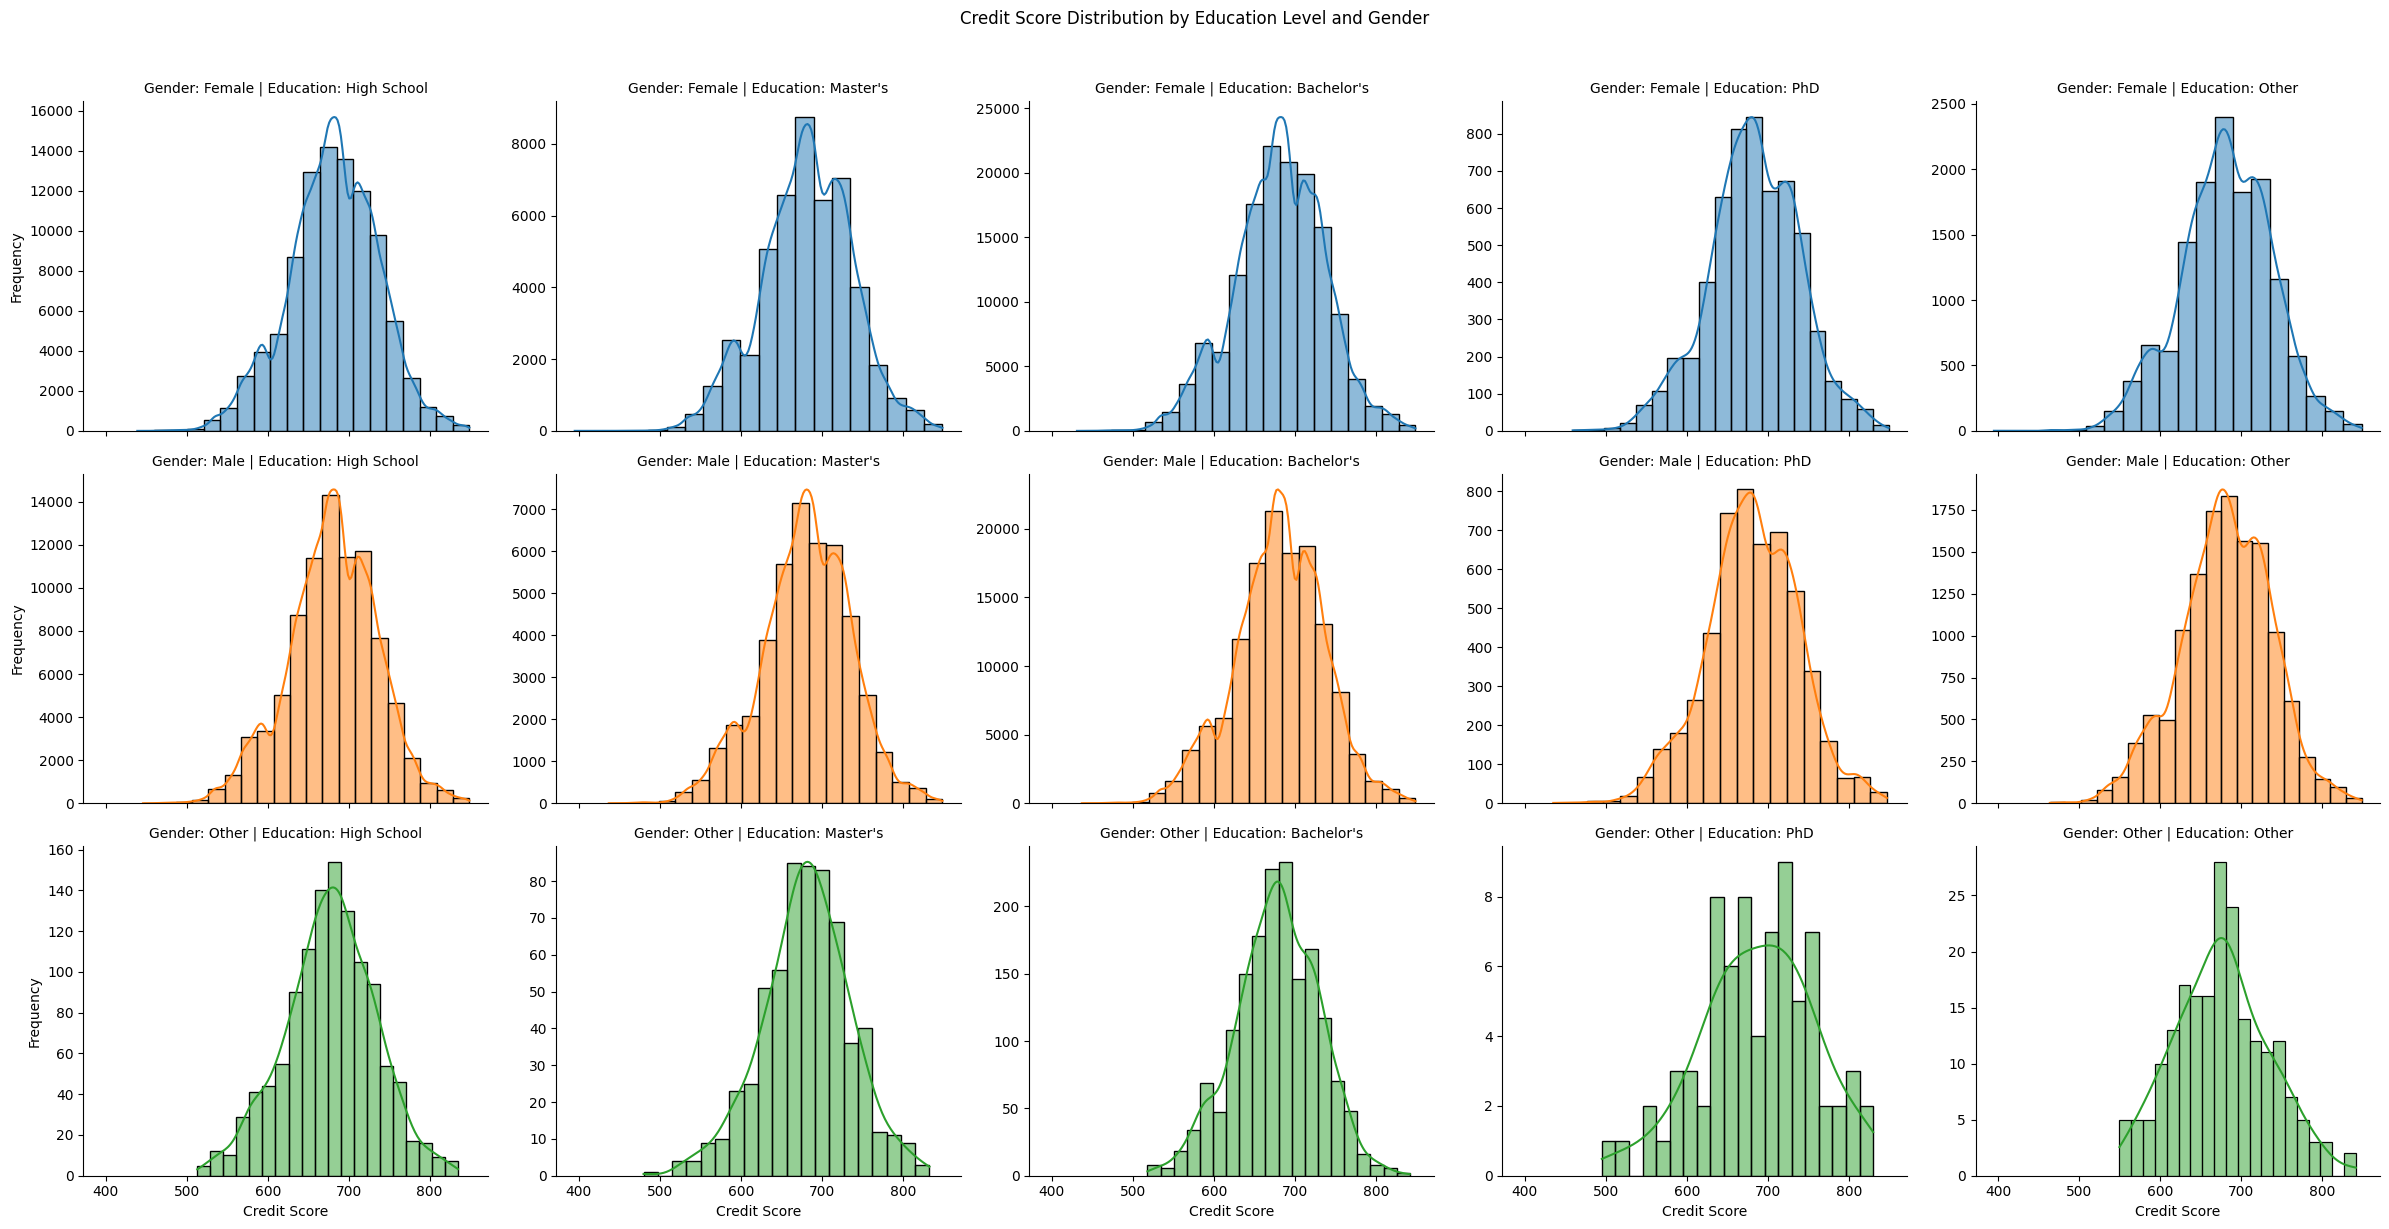

In [4]:
g = sns.FacetGrid(df, col='education_level', row='gender', hue='gender', height=4, aspect=1.2, sharey=False)
g.map(sns.histplot, 'credit_score', bins=20, kde=True)
g.set_axis_labels('Credit Score', 'Frequency')
g.set_titles(col_template='Education: {col_name}', row_template='Gender: {row_name}')
plt.suptitle('Credit Score Distribution by Education Level and Gender', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

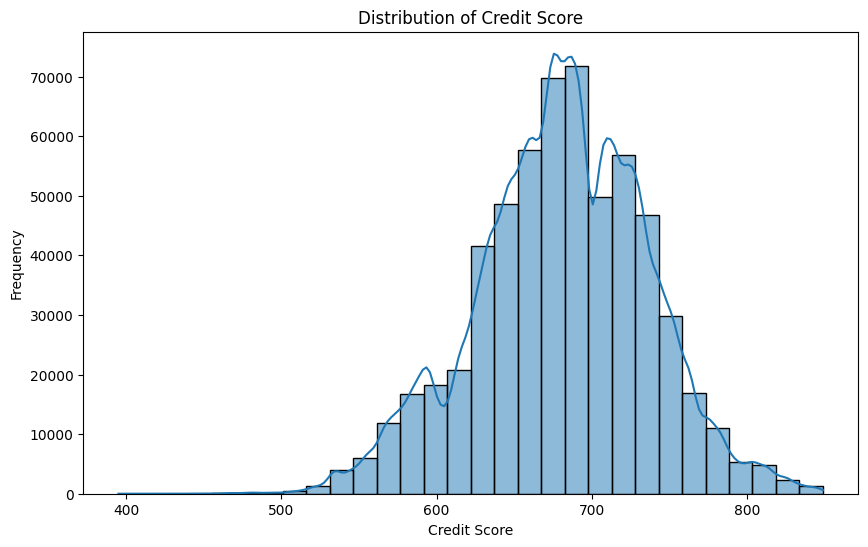

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['credit_score'], bins=30, kde=True)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

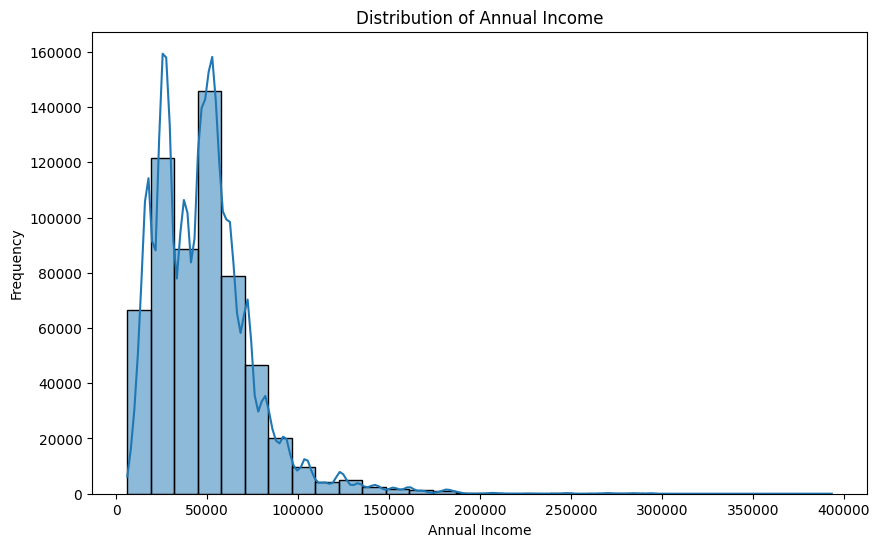

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['annual_income'], bins=30, kde=True)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

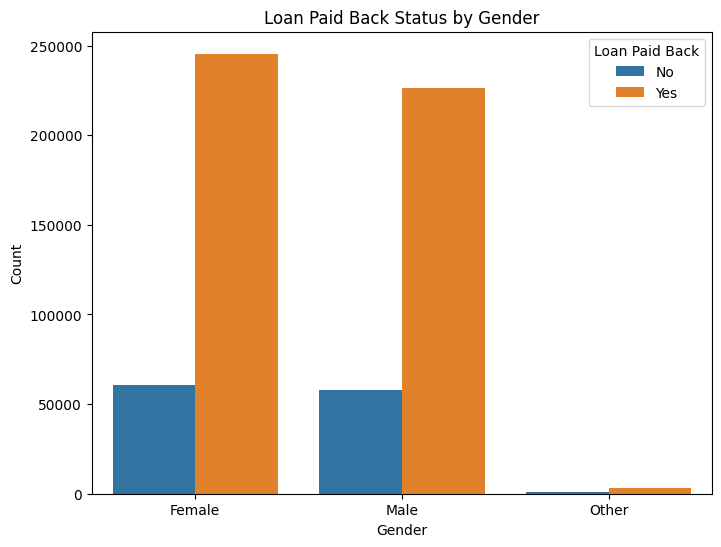

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', hue='loan_paid_back', data=df)
plt.title('Loan Paid Back Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Loan Paid Back', labels=['No', 'Yes'])
plt.show()

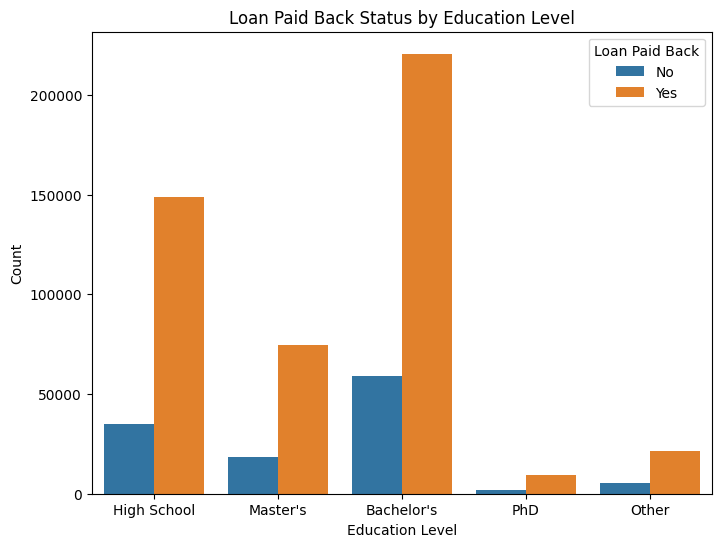

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='education_level', hue='loan_paid_back', data=df)
plt.title('Loan Paid Back Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Loan Paid Back', labels=['No', 'Yes'])
plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [10]:
df.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [11]:
X=df.drop(columns=['loan_paid_back','id'])
y=df['loan_paid_back']

In [12]:
y.value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [13]:
numeric_features =pd.DataFrame(X.select_dtypes(include=['int64', 'float64']))

In [14]:
numeric_features.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate'],
      dtype='object')

In [15]:
category_features =pd.DataFrame(X.select_dtypes(include=['object']))

In [16]:
category_features.columns

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [17]:
from sklearn.model_selection import  train_test_split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [19]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [20]:
from sklearn.compose import ColumnTransformer

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features.columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), category_features.columns),
    ]
)

In [34]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [24]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=500,
        n_jobs=-1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        n_jobs=-1,
        tree_method="hist",  
        random_state=42,
    )}

In [25]:
from sklearn.pipeline import Pipeline

In [26]:
from sklearn.metrics import roc_auc_score

In [27]:
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)

    # use predicted probability of class 1
    y_valid_proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_valid_proba)

    results.append((name, auc))
    print(f"{name} ROC-AUC: {auc:.5f}")

# Sort results by AUC
results = sorted(results, key=lambda x: x[1], reverse=True)

print("\n=== Model ranking (by ROC-AUC) ===")
for name, auc in results:
    print(f"{name}: {auc:.5f}")


Training LogisticRegression...
LogisticRegression ROC-AUC: 0.91034

Training RandomForest...
RandomForest ROC-AUC: 0.91012

Training ExtraTrees...
ExtraTrees ROC-AUC: 0.90620

Training GradientBoosting...
GradientBoosting ROC-AUC: 0.91488

Training XGBoost...
XGBoost ROC-AUC: 0.91784

=== Model ranking (by ROC-AUC) ===
XGBoost: 0.91784
GradientBoosting: 0.91488
LogisticRegression: 0.91034
RandomForest: 0.91012
ExtraTrees: 0.90620


In [28]:
import joblib
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier


best_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    n_jobs=-1,
    tree_method="hist",
    random_state=42
)

final_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", best_model)
])

final_clf.fit(X, y)

joblib.dump(final_clf, "loan_model_pipeline.pkl")
print("save loan_model_pipeline.pkl")


save loan_model_pipeline.pkl
